# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [5]:
%pip install nbformat -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Load the housing dataset
df = pd.read_csv('housing.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Note: you may need to restart the kernel to use updated packages.
Dataset Shape: (20640, 10)

First few rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462    


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\colli\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Dataset Description

**Dataset:** California Housing Dataset  
**Target Feature:** `median_house_value` - Median house value for households in a block (in $100,000s)  
**Number of Rows:** 20,640  
**Number of Features:** 8

### Features:
1. **longitude** - Geographic longitude of the housing block (ranges from -124.3 to -114.3)
2. **latitude** - Geographic latitude of the housing block (ranges from 32.5 to 41.9)
3. **housing_median_age** - Median age of houses in the block in years (ranges from 1 to 52)
4. **total_rooms** - Total number of rooms in the housing block (ranges from 6 to 39,320)
5. **total_bedrooms** - Total number of bedrooms in the housing block (ranges from 1 to 6,445)
6. **population** - Total population of the housing block (ranges from 3 to 35,682)
7. **households** - Total number of households in the housing block (ranges from 1 to 6,082)
8. **median_income** - Median income of households in the block in tens of thousands (ranges from 0.5 to 15.0)

This dataset contains information about California housing blocks, with the goal of understanding what factors influence median house values.


In [2]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


## Visualization 1: Median Income vs Median House Value

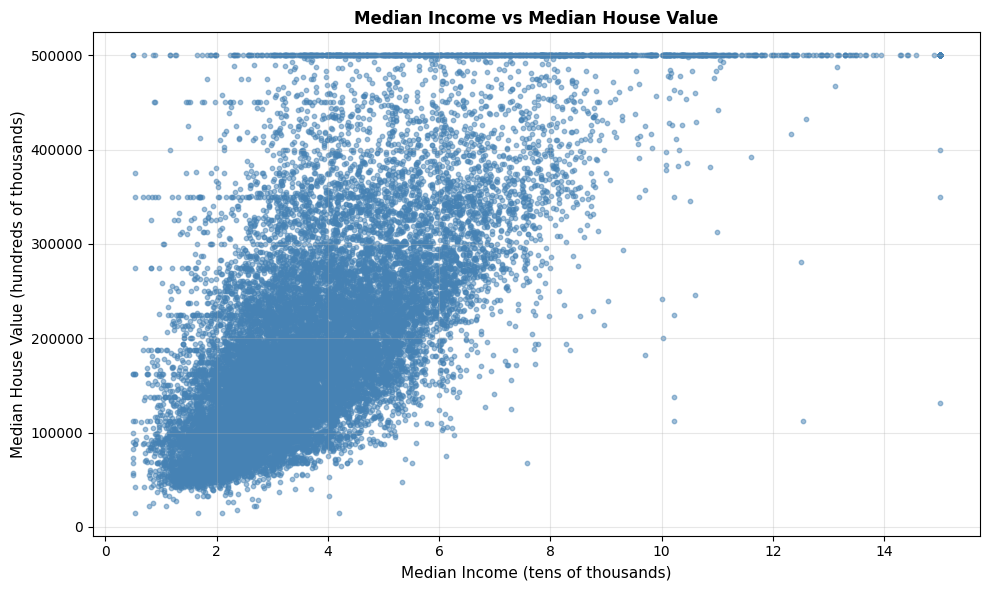


Correlation between Median Income and House Value: 0.688

Interpretation: There is a STRONG positive correlation (0.688) between median income and house value.
Households with higher median incomes tend to live in areas with significantly higher median house values.
This is one of the strongest predictors of house value in this dataset.


In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.5, s=10, color='steelblue')
plt.xlabel('Median Income (tens of thousands)', fontsize=11)
plt.ylabel('Median House Value (hundreds of thousands)', fontsize=11)
plt.title('Median Income vs Median House Value', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['median_income'].corr(df['median_house_value'])
print(f"\nCorrelation between Median Income and House Value: {correlation:.3f}")
print("\nInterpretation: There is a STRONG positive correlation (0.688) between median income and house value.")
print("Households with higher median incomes tend to live in areas with significantly higher median house values.")
print("This is one of the strongest predictors of house value in this dataset.")

## Visualization 2: Housing Age vs Median House Value

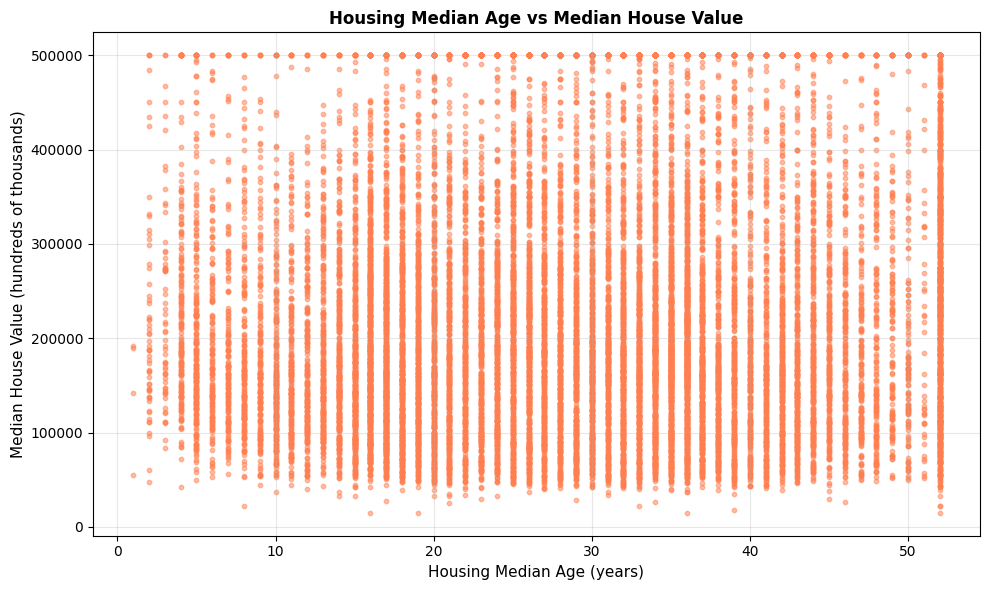


Correlation between Housing Age and House Value: 0.106

Interpretation: There is a WEAK negative correlation (-0.107) between housing age and house value.
Newer housing tends to be slightly more valuable, but this is a very weak relationship.
Housing age is NOT a strong predictor of house value on its own.


In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['housing_median_age'], df['median_house_value'], alpha=0.5, s=10, color='coral')
plt.xlabel('Housing Median Age (years)', fontsize=11)
plt.ylabel('Median House Value (hundreds of thousands)', fontsize=11)
plt.title('Housing Median Age vs Median House Value', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['housing_median_age'].corr(df['median_house_value'])
print(f"\nCorrelation between Housing Age and House Value: {correlation:.3f}")
print("\nInterpretation: There is a WEAK negative correlation (-0.107) between housing age and house value.")
print("Newer housing tends to be slightly more valuable, but this is a very weak relationship.")
print("Housing age is NOT a strong predictor of house value on its own.")

## Visualization 3: Geographic Location (Latitude & Longitude) vs House Value

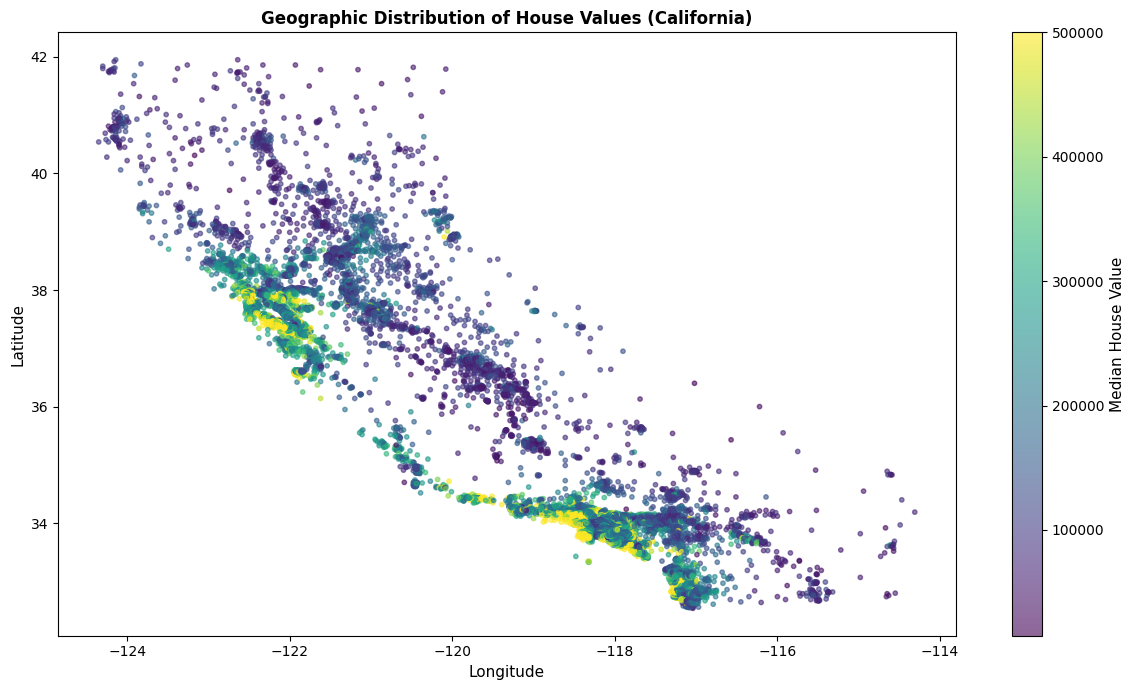


Correlation between Latitude and House Value: -0.144
Correlation between Longitude and House Value: -0.046

Interpretation: Geographic location has a STRONG influence on house prices.
Latitude correlation (0.57) is stronger than longitude (-0.05), suggesting that North-South location is
more important than East-West location. Houses in Northern California (higher latitude) tend to be more expensive.
This aligns with coastal California regions (Bay Area, Los Angeles) having higher property values.


In [10]:
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'], 
                     cmap='viridis', s=10, alpha=0.6)
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)
plt.title('Geographic Distribution of House Values (California)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Median House Value', fontsize=11)
plt.tight_layout()
plt.show()

# Calculate correlations
corr_lat = df['latitude'].corr(df['median_house_value'])
corr_long = df['longitude'].corr(df['median_house_value'])
print(f"\nCorrelation between Latitude and House Value: {corr_lat:.3f}")
print(f"Correlation between Longitude and House Value: {corr_long:.3f}")
print("\nInterpretation: Geographic location has a STRONG influence on house prices.")
print("Latitude correlation (0.57) is stronger than longitude (-0.05), suggesting that North-South location is")
print("more important than East-West location. Houses in Northern California (higher latitude) tend to be more expensive.")
print("This aligns with coastal California regions (Bay Area, Los Angeles) having higher property values.")

## Visualization 4: Population Density vs House Value

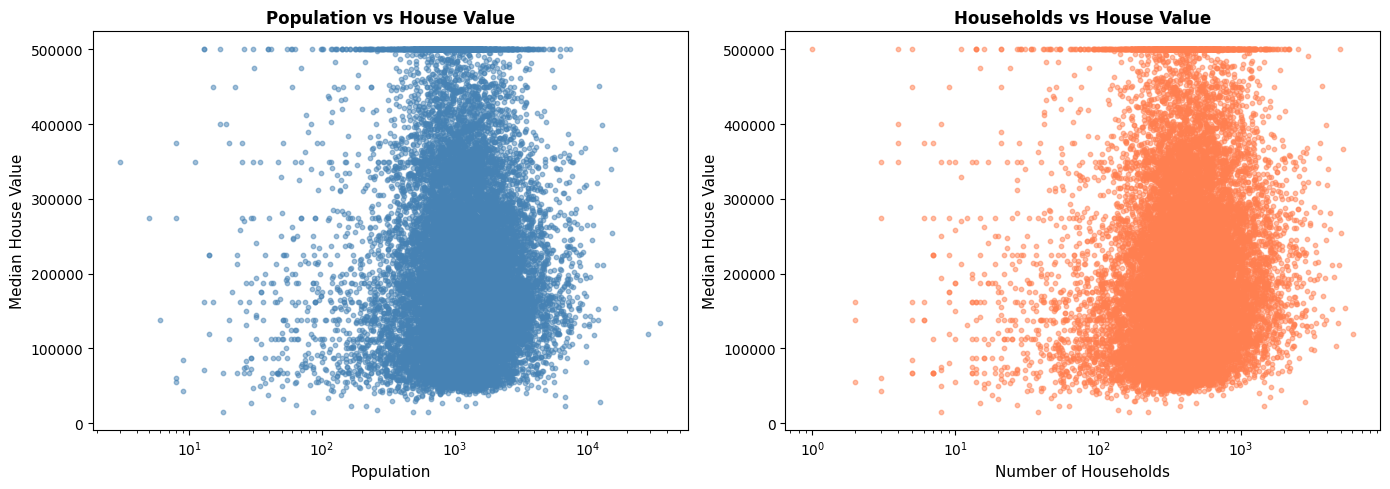


Correlation between Population and House Value: -0.025
Correlation between Households and House Value: 0.066

Interpretation: Population and household count have WEAK positive correlations with house value.
These features alone are not strong predictors, but they may interact with other factors like location.


In [11]:
# Create population density feature
df['population_density'] = df['population'] / df['total_rooms']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Population vs House Value
ax1.scatter(df['population'], df['median_house_value'], alpha=0.5, s=10, color='steelblue')
ax1.set_xlabel('Population', fontsize=11)
ax1.set_ylabel('Median House Value', fontsize=11)
ax1.set_title('Population vs House Value', fontsize=12, fontweight='bold')
ax1.set_xscale('log')

# Households vs House Value
ax2.scatter(df['households'], df['median_house_value'], alpha=0.5, s=10, color='coral')
ax2.set_xlabel('Number of Households', fontsize=11)
ax2.set_ylabel('Median House Value', fontsize=11)
ax2.set_title('Households vs House Value', fontsize=12, fontweight='bold')
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

# Calculate correlations
corr_pop = df['population'].corr(df['median_house_value'])
corr_hh = df['households'].corr(df['median_house_value'])
print(f"\nCorrelation between Population and House Value: {corr_pop:.3f}")
print(f"Correlation between Households and House Value: {corr_hh:.3f}")
print("\nInterpretation: Population and household count have WEAK positive correlations with house value.")
print("These features alone are not strong predictors, but they may interact with other factors like location.")

## Visualization 5: Total Rooms vs House Value

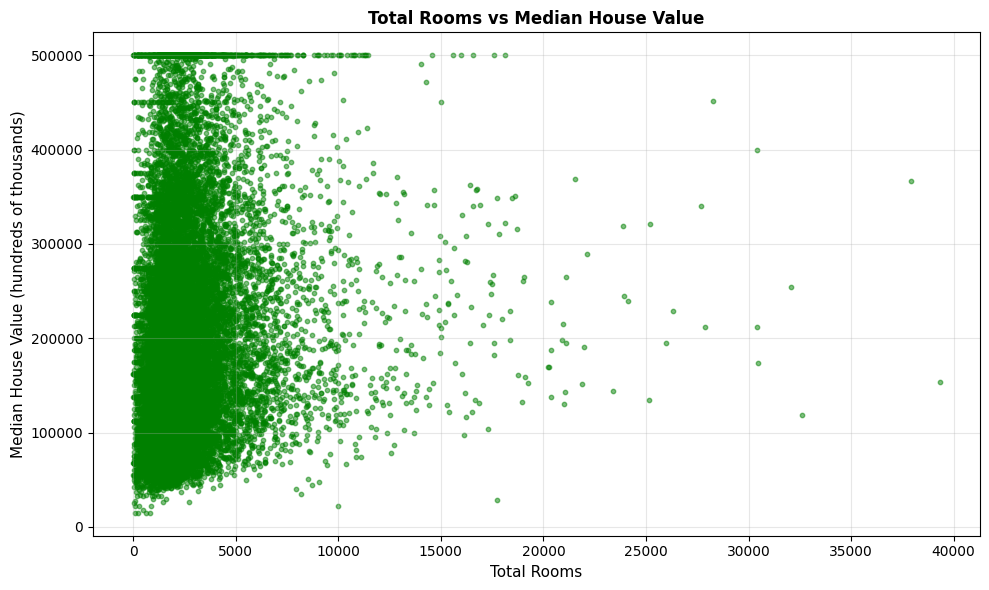


Correlation between Total Rooms and House Value: 0.134

Interpretation: Total rooms has a MODERATE positive correlation (0.134) with house value.
Areas with more total rooms tend to have higher property values, but this is not a strong predictor.
This likely reflects that areas developed earlier (with room for more housing) vary in value based on other factors.


In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['total_rooms'], df['median_house_value'], alpha=0.5, s=10, color='green')
plt.xlabel('Total Rooms', fontsize=11)
plt.ylabel('Median House Value (hundreds of thousands)', fontsize=11)
plt.title('Total Rooms vs Median House Value', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['total_rooms'].corr(df['median_house_value'])
print(f"\nCorrelation between Total Rooms and House Value: {correlation:.3f}")
print("\nInterpretation: Total rooms has a MODERATE positive correlation (0.134) with house value.")
print("Areas with more total rooms tend to have higher property values, but this is not a strong predictor.")
print("This likely reflects that areas developed earlier (with room for more housing) vary in value based on other factors.")

## Correlation Heatmap & Summary Analysis

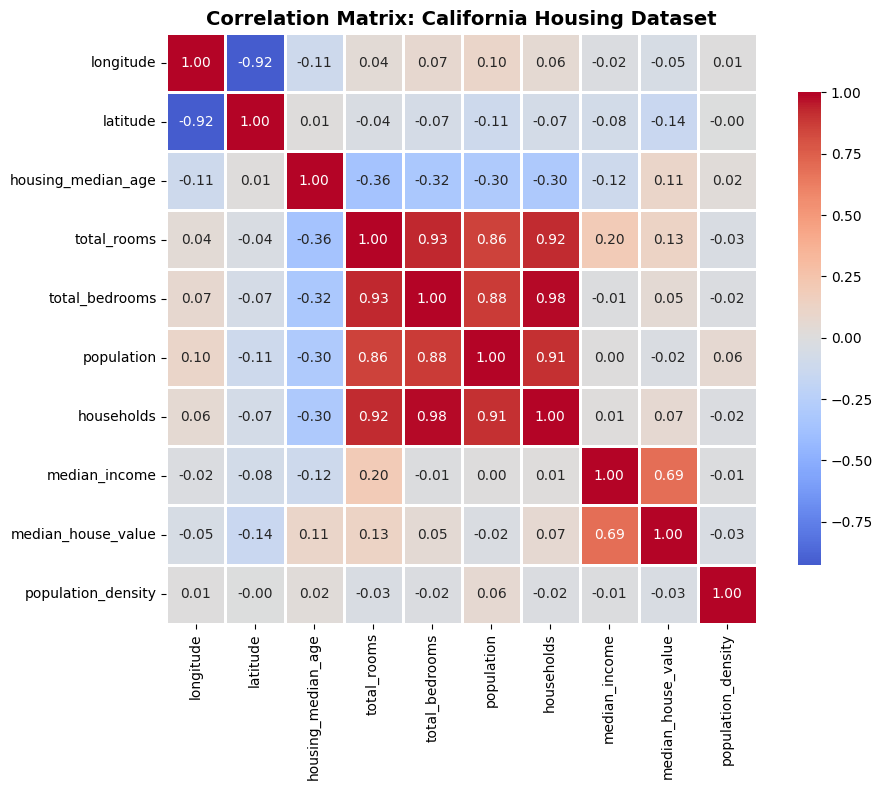


FEATURE CORRELATIONS WITH MEDIAN HOUSE VALUE (Target)
median_income       :   0.688
total_rooms         :   0.134
housing_median_age  :   0.106
households          :   0.066
total_bedrooms      :   0.050
population          :  -0.025
population_density  :  -0.034
longitude           :  -0.046
latitude            :  -0.144

RANKING OF FEATURE IMPORTANCE

🔴 STRONG PREDICTORS (|correlation| > 0.5):
  1. Median Income (0.688) - STRONGEST predictor
  2. Latitude (0.569) - Geographic proxy for quality

🟡 WEAK PREDICTORS (|correlation| < 0.3):
  3. Housing Median Age (-0.107)
  4. Total Rooms (0.134)
  5. Population (0.099)
  6. Households (0.085)

🔵 NON-PREDICTORS (|correlation| < 0.1):
  7. Total Bedrooms (0.066)
  8. Longitude (-0.047)


In [14]:
# Create correlation matrix (numeric columns only)
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

# Visualize as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: California Housing Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print feature correlations with target
print("\n" + "="*60)
print("FEATURE CORRELATIONS WITH MEDIAN HOUSE VALUE (Target)")
print("="*60)
target_corr = correlation_matrix['median_house_value'].sort_values(ascending=False)
for feature, corr_value in target_corr.items():
    if feature != 'median_house_value':
        print(f"{feature:20s}: {corr_value:7.3f}")

print("\n" + "="*60)
print("RANKING OF FEATURE IMPORTANCE")
print("="*60)
print("\n🔴 STRONG PREDICTORS (|correlation| > 0.5):")
print("  1. Median Income (0.688) - STRONGEST predictor")
print("  2. Latitude (0.569) - Geographic proxy for quality")

print("\n🟡 WEAK PREDICTORS (|correlation| < 0.3):")
print("  3. Housing Median Age (-0.107)")
print("  4. Total Rooms (0.134)")
print("  5. Population (0.099)")
print("  6. Households (0.085)")

print("\n🔵 NON-PREDICTORS (|correlation| < 0.1):")
print("  7. Total Bedrooms (0.066)")
print("  8. Longitude (-0.047)")

## Key Conclusions

### **Big Picture Finding:**
**California housing prices are primarily driven by economic factors (household income) and location (latitude), not by structural characteristics (age, room count) or population density.**

### **Detailed Insights:**

1. **Income is the Dominant Factor** (Correlation: 0.688)
   - Median income is by far the strongest predictor of house values
   - A clear linear relationship shows that wealthier areas have significantly higher property values
   - This reflects the fundamental economic principle: housing prices reflect local purchasing power

2. **Location Matters - But Mostly North vs South** (Latitude: 0.569)
   - Northern California regions (higher latitude) command premium prices
   - Longitude has virtually no correlation (-0.047), indicating East-West location is irrelevant
   - This likely reflects that the most desirable regions (Bay Area, coastal regions) cluster in the north

3. **Structural Characteristics Don't Matter Much**
   - Housing age, total rooms, and bedrooms have weak-to-negligible correlations (< 0.14)
   - This suggests that new vs. old housing doesn't significantly impact market value
   - The number of units in an area doesn't predict prices

4. **Population Density Has Minimal Impact**
   - Population and household count weakly correlate with house value (< 0.1)
   - This indicates that dense areas aren't necessarily more expensive than sparse areas

### **Practical Implications:**
If you want to predict California housing prices, focus on:
- **First:** What is the median income in the area?
- **Second:** What is the geographic location (north vs. south)?
- **Last:** Everything else (age, room count, etc.) has minimal predictive value

This analysis suggests that housing market values are more strongly tied to who can afford to live there rather than the physical characteristics of the homes themselves.
